### This code provides supports for results on Regression Analyses of A, including those in Main Text section 2.3.

In [1]:
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.lines as mlines


d:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
###data source 1: census data
df_census_all=pd.read_csv('data/census/all_census_data_with_location.csv')
###data source 1: census data

df_census_all['census_block_group']=df_census_all['census_block_group'].astype(str)

In [3]:
#input
dict_state={'1': 'AL', '2': 'AK', '4': 'AZ', '5': 'AR', '6': 'CA', '8': 'CO', '9': 'CT', '10': 'DE', '11': 'DC', '12': 'FL',
            '13': 'GA', '15': 'HI', '16': 'ID','17': 'IL', '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME', 
            '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS', '29': 'MO','30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH', 
            '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND', '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA','44': 'RI', 
            '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI', 
            '56': 'WY', '60': 'AS', '66': 'GU', '69': 'MP', '72': 'PR', '74': 'UM', '78': 'VI'}

def class_sig(pv):
    if pv<0.001:
        return '***'
    elif pv<0.01:
        return '**'
    elif pv<0.05:
        return '*'
    else:
        return 'NS' 

country-wide regression

In [4]:

for key in ['Health Care Services','Grocery and Food Supply','Housing and Real Estate']:
    col=['census_block_group','ParentType','num_accessible_facility','demand_ratios','demand_met_in_local']
###data source 2: accratio data 5 mile   
    homoPath='data/A under 5-mile setting/'+key+'.csv'
    df_reg=pd.read_csv(homoPath,usecols=col)
###data source 2: accratio data 5 mile
    
    

    df_reg['census_block_group']=df_reg['census_block_group'].astype(str)

    df_reg=pd.merge(df_reg,df_census_all, how='left',on='census_block_group')

    df_reg['dum_age']=df_reg.apply(lambda x: 1 if x['percent_above_65']>0.5 else 0.5 ,axis=1)
    df_reg['dum_age']=df_reg.apply(lambda x: 0 if x['percent_above_65']<0.2 else x['dum_age'] ,axis=1)
    
    df_reg=df_reg[df_reg['dum_age']!=0.5]
    #homo
    df_reg=df_reg.dropna()

    num_obs=len(df_reg)
    num_old_obs=len(df_reg[df_reg['dum_age']==1])
    
    df_reg['state']=df_reg['state'].astype(int)

    if (num_obs>0) &(num_old_obs>0):

        y=df_reg.loc[:,['demand_met_in_local']]

        
        if key =='Health Care Services':
            reg4_X=['dum_age','demand_ratios',
                       'median_income_normalized by 250000','percent_undergraduate or higher','percent_minority','Pct_E8_Hlth',
                         'E_PctLowWage', 'NatWalkInd', 'isUrban',
                        'state']
        elif key =='Grocery and Food Supply':
            reg4_X=['dum_age','demand_ratios',
                       'median_income_normalized by 250000','percent_undergraduate or higher','percent_minority',
                        'Pct_E8_Ret', 'E_PctLowWage', 'NatWalkInd', 'isUrban',
                        'state'] 
        else:
            reg4_X=['dum_age','demand_ratios',
                       'median_income_normalized by 250000','percent_undergraduate or higher','percent_minority',
                         'Pct_E8_Svc', 'E_PctLowWage', 'NatWalkInd', 'isUrban',
                        'state']             

                
        x4=df_reg.loc[:,reg4_X]
        x4=sm.add_constant(x4)
        model4=sm.OLS(y,x4).fit()   
        
        print(model4.summary())
        print(key)
        

                             OLS Regression Results                            
Dep. Variable:     demand_met_in_local   R-squared:                       0.373
Model:                             OLS   Adj. R-squared:                  0.372
Method:                  Least Squares   F-statistic:                     9407.
Date:                 Thu, 20 Mar 2025   Prob (F-statistic):               0.00
Time:                         22:39:23   Log-Likelihood:                 18276.
No. Observations:               158459   AIC:                        -3.653e+04
Df Residuals:                   158448   BIC:                        -3.642e+04
Df Model:                           10                                         
Covariance Type:             nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

state-wide regression

In [5]:
#input
dict_epsg={'1': '32616', '2': '32606', '4': '32612', '5': '32615', '6': '32611', '8': '32613', '9': '32618', '10': '32618', '11': '32618', '12': '32617', 
           '13': '32616', '15': '32604', '16': '32611', '17': '32616', '18': '32616', '19': '32615', '20': '32614', '21': '32616', '22': '32615', '23': '32619', 
           '24': '32618', '25': '32619', '26': '32617', '27': '32615', '28': '32616', '29': '32615', '30': '32612', '31': '32614', '32': '32611', '33': '32619', 
           '34': '32618', '35': '32613', '36': '32618', '37': '32617', '38': '32614', '39': '32617', '40': '32614', '41': '32610', '42': '32618', '44': '32619', 
           '45': '32617', '46': '32614', '47': '32616', '48': '32614', '49': '32612', '50': '32618', '51': '32618', '53': '32610', '54': '32617', '55': '32616', 
           '56': '32613', '72': '32619'}
dict_state={'1': 'AL', '2': 'AK', '4': 'AZ', '5': 'AR', '6': 'CA', '8': 'CO', '9': 'CT', '10': 'DE', '11': 'DC', '12': 'FL', '13': 'GA', '15': 'HI', '16': 'ID',
            '17': 'IL', '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME', '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS', '29': 'MO',
            '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH', '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND', '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', 
            '44': 'RI', '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI', '56': 'WY', '60': 'AS', 
            '66': 'GU', '69': 'MP', '72': 'PR', '74': 'UM', '78': 'VI'}

In [7]:
homoRegResult=[]



listHGH=['Health Care Services',
                 'Grocery and Food Supply',
                 'Housing and Real Estate']

for key in listHGH: 

###data source 2: accratio data 5 mile       
    homoPath='data/A under 5-mile setting/'+key+'.csv'
    col=['census_block_group','ParentType','num_accessible_facility','demand_ratios','demand_met_in_local']
    df_reg=pd.read_csv(homoPath,usecols=col)
###data source 2: accratio data 5 mile   


    df_reg['census_block_group']=df_reg['census_block_group'].astype(str)

    df_reg=pd.merge(df_reg,df_census_all, how='left',on='census_block_group')

    df_reg['dum_age']=df_reg.apply(lambda x: 1 if x['percent_above_65']>0.5 else 0.5 ,axis=1)
    df_reg['dum_age']=df_reg.apply(lambda x: 0 if x['percent_above_65']<0.2 else x['dum_age'] ,axis=1)
    
    df_reg=df_reg[df_reg['dum_age']!=0.5]
    #homo
    df_reg=df_reg.dropna()


    
    print('read data_'+key)
    
    for fip in dict_epsg.keys():
        state=dict_state[fip]
        print(len(df_reg[df_reg['state']==int(fip)]),state)
        #homo
        df_reg_state=df_reg[(df_reg['state']==int(fip))&(df_reg['dum_age']!=0.5)]

        num_obs=len(df_reg_state)
        
        num_old_obs=sum(df_reg_state['dum_age'])
        if (num_obs>0) &(num_old_obs>0):

            y=df_reg_state.loc[:,['demand_met_in_local']]

            if key =='Health Care Services':
                regx3=['dum_age','demand_ratios',
                        'median_income_normalized by 250000','percent_undergraduate or higher','percent_minority','Pct_E8_Hlth',
                            'E_PctLowWage', 'NatWalkInd', 'isUrban']
            elif key =='Grocery and Food Supply':
                regx3=['dum_age','demand_ratios',
                        'median_income_normalized by 250000','percent_undergraduate or higher','percent_minority',
                            'Pct_E8_Ret', 'E_PctLowWage', 'NatWalkInd', 'isUrban'] 
            else:
                regx3=['dum_age','demand_ratios',
                        'median_income_normalized by 250000','percent_undergraduate or higher','percent_minority',
                            'Pct_E8_Svc', 'E_PctLowWage', 'NatWalkInd', 'isUrban']    

            x3=df_reg_state.loc[:,regx3]
            x3=sm.add_constant(x3)
            
            model3=sm.OLS(y,x3).fit()

            homoRegResult.append((key,state,num_obs,num_old_obs,
                               model3.params[1],class_sig(model3.pvalues[1]),
                                 model3.conf_int()[0][1],model3.conf_int()[1][1]
                                 ))

        
        print(state+'_'+key+'_homo done')
        

dfHomoRegResultPa=pd.DataFrame(homoRegResult,columns=['ParentType','state','num_obs','num_old_obs',
                                                                                   'coeff_regC_4_ctrls','signif_regC',
                                                     'coeff_lowci','coeff_upperci']) 



read data_Health Care Services
2357 AL
AL_Health Care Services_homo done
445 AK
AK_Health Care Services_homo done
3091 AZ
AZ_Health Care Services_homo done
1455 AR
AR_Health Care Services_homo done
18206 CA
CA_Health Care Services_homo done
2738 CO
CO_Health Care Services_homo done
1846 CT
CT_Health Care Services_homo done
372 DE
DE_Health Care Services_homo done
366 DC
DC_Health Care Services_homo done
7493 FL
FL_Health Care Services_homo done
4331 GA
GA_Health Care Services_homo done
533 HI
HI_Health Care Services_homo done
683 ID
ID_Health Care Services_homo done
7260 IL
IL_Health Care Services_homo done
3605 IN
IN_Health Care Services_homo done
1794 IA
IA_Health Care Services_homo done
1695 KS
KS_Health Care Services_homo done
2407 KY
KY_Health Care Services_homo done
2531 LA
LA_Health Care Services_homo done
621 ME
ME_Health Care Services_homo done
2955 MD
MD_Health Care Services_homo done
3577 MA
MA_Health Care Services_homo done
5741 MI
MI_Health Care Services_homo done
3032 MN


C:\Users\Linao\AppData\Local\Temp\ipykernel_7856\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_7856\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_7856\3768005585.py:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mod

1383 NV
NV_Health Care Services_homo done
621 NH
NH_Health Care Services_homo done
4887 NJ
NJ_Health Care Services_homo done
977 NM
NM_Health Care Services_homo done
11045 NY
NY_Health Care Services_homo done
4321 NC
NC_Health Care Services_homo done
389 ND
ND_Health Care Services_homo done
6476 OH
OH_Health Care Services_homo done
2232 OK
OK_Health Care Services_homo done
1768 OR
OR_Health Care Services_homo done
6548 PA
PA_Health Care Services_homo done
552 RI
RI_Health Care Services_homo done
2092 SC
SC_Health Care Services_homo done
431 SD
SD_Health Care Services_homo done
2911 TN
TN_Health Care Services_homo done
12399 TX
TX_Health Care Services_homo done
1488 UT
UT_Health Care Services_homo done
336 VT
VT_Health Care Services_homo done
3856 VA
VA_Health Care Services_homo done
3610 WA
WA_Health Care Services_homo done
936 WV
WV_Health Care Services_homo done
3337 WI
WI_Health Care Services_homo done
303 WY
WY_Health Care Services_homo done
0 PR
PR_Health Care Services_homo done


C:\Users\Linao\AppData\Local\Temp\ipykernel_7856\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_7856\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_7856\3768005585.py:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mod

read data_Grocery and Food Supply
2354 AL
AL_Grocery and Food Supply_homo done
440 AK
AK_Grocery and Food Supply_homo done
3092 AZ
AZ_Grocery and Food Supply_homo done
1453 AR
AR_Grocery and Food Supply_homo done
18220 CA
CA_Grocery and Food Supply_homo done
2742 CO
CO_Grocery and Food Supply_homo done
1845 CT
CT_Grocery and Food Supply_homo done
374 DE
DE_Grocery and Food Supply_homo done
367 DC
DC_Grocery and Food Supply_homo done
7496 FL
FL_Grocery and Food Supply_homo done
4334 GA
GA_Grocery and Food Supply_homo done
534 HI
HI_Grocery and Food Supply_homo done
685 ID
ID_Grocery and Food Supply_homo done
7266 IL
IL_Grocery and Food Supply_homo done
3604 IN
IN_Grocery and Food Supply_homo done
1794 IA
IA_Grocery and Food Supply_homo done
1696 KS
KS_Grocery and Food Supply_homo done
2406 KY
KY_Grocery and Food Supply_homo done
2535 LA
LA_Grocery and Food Supply_homo done
620 ME
ME_Grocery and Food Supply_homo done
2953 MD
MD_Grocery and Food Supply_homo done
3583 MA
MA_Grocery and Foo

C:\Users\Linao\AppData\Local\Temp\ipykernel_7856\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_7856\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_7856\3768005585.py:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mod

NJ_Grocery and Food Supply_homo done
968 NM
NM_Grocery and Food Supply_homo done
11067 NY
NY_Grocery and Food Supply_homo done
4323 NC
NC_Grocery and Food Supply_homo done
388 ND
ND_Grocery and Food Supply_homo done
6482 OH
OH_Grocery and Food Supply_homo done
2230 OK
OK_Grocery and Food Supply_homo done
1768 OR
OR_Grocery and Food Supply_homo done
6546 PA
PA_Grocery and Food Supply_homo done
550 RI
RI_Grocery and Food Supply_homo done
2093 SC
SC_Grocery and Food Supply_homo done
429 SD
SD_Grocery and Food Supply_homo done
2911 TN
TN_Grocery and Food Supply_homo done
12397 TX
TX_Grocery and Food Supply_homo done
1487 UT
UT_Grocery and Food Supply_homo done
339 VT
VT_Grocery and Food Supply_homo done
3860 VA
VA_Grocery and Food Supply_homo done
3614 WA
WA_Grocery and Food Supply_homo done
932 WV
WV_Grocery and Food Supply_homo done
3339 WI
WI_Grocery and Food Supply_homo done
306 WY
WY_Grocery and Food Supply_homo done
0 PR
PR_Grocery and Food Supply_homo done
read data_Housing and Real

C:\Users\Linao\AppData\Local\Temp\ipykernel_7856\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_7856\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_7856\3768005585.py:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mod

NY_Housing and Real Estate_homo done
4320 NC
NC_Housing and Real Estate_homo done
389 ND
ND_Housing and Real Estate_homo done
6491 OH
OH_Housing and Real Estate_homo done
2231 OK
OK_Housing and Real Estate_homo done
1763 OR
OR_Housing and Real Estate_homo done
6553 PA
PA_Housing and Real Estate_homo done
552 RI
RI_Housing and Real Estate_homo done
2093 SC
SC_Housing and Real Estate_homo done
428 SD
SD_Housing and Real Estate_homo done
2909 TN
TN_Housing and Real Estate_homo done
12399 TX
TX_Housing and Real Estate_homo done
1489 UT
UT_Housing and Real Estate_homo done
338 VT
VT_Housing and Real Estate_homo done
3863 VA
VA_Housing and Real Estate_homo done
3616 WA
WA_Housing and Real Estate_homo done
938 WV
WV_Housing and Real Estate_homo done
3335 WI
WI_Housing and Real Estate_homo done
306 WY
WY_Housing and Real Estate_homo done
0 PR
PR_Housing and Real Estate_homo done


C:\Users\Linao\AppData\Local\Temp\ipykernel_7856\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_7856\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_7856\3768005585.py:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mod

In [8]:
dfHomoRegResultPa

,ParentType,state,num_obs,num_old_obs,coeff_regC_4_ctrls,signif_regC,coeff_lowci,coeff_upperci
0,Health Care Services,AL,2357,9.0,0.107884,NS,-0.033441,0.249208
1,Health Care Services,AZ,3091,256.0,0.041610,**,0.011506,0.071715
2,Health Care Services,AR,1455,13.0,-0.018141,NS,-0.135505,0.099223
3,Health Care Services,CA,18206,204.0,0.026420,NS,-0.002892,0.055732
4,Health Care Services,CO,2738,17.0,0.074448,NS,-0.027794,0.176689
...,...,...,...,...,...,...,...,...
132,Housing and Real Estate,UT,1489,3.0,-0.394962,**,-0.643484,-0.146441
133,Housing and Real Estate,VA,3863,32.0,0.088889,**,0.028336,0.149443
134,Housing and Real Estate,WA,3616,31.0,0.121289,**,0.044420,0.198158
135,Housing and Real Estate,WV,938,4.0,0.093843,NS,-0.101830,0.289517


In [ ]:
#dfHomoRegResultPa.to_csv(r'..\..\..\R1\new results\regression\state_HGH_regression_data.csv')

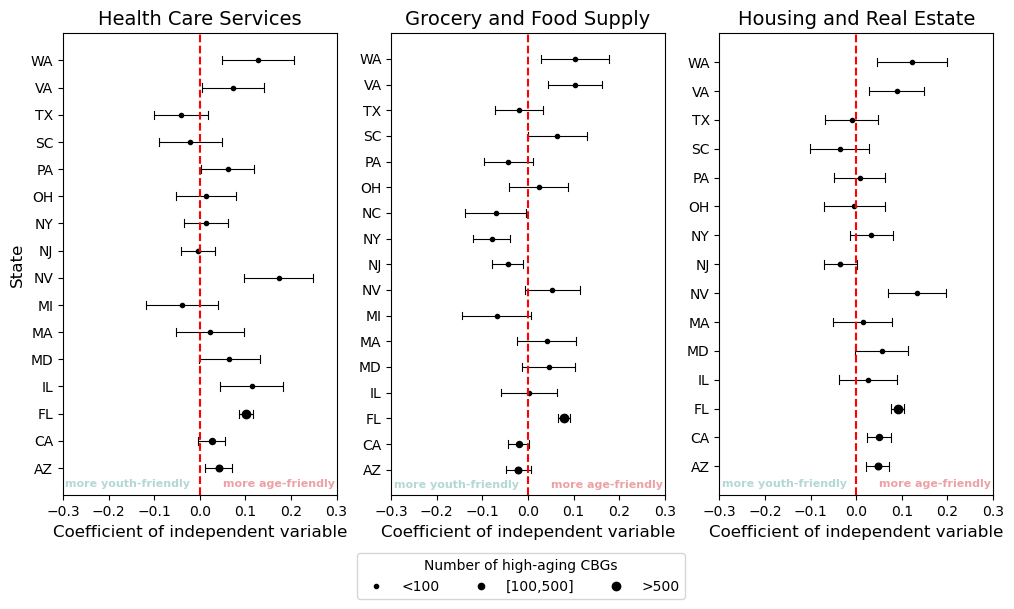

In [9]:
#visualization

lowOldNum=30
fig,ax=plt.subplots(1,3,figsize=(12,6))

colors={'less than or equal to 0.5':'#B3D8D5','greater than 0.5': '#EDA1A4'}

listHGH=['Health Care Services',
                 'Grocery and Food Supply',
                 'Housing and Real Estate']

for k,key in enumerate(listHGH): 
    df=dfHomoRegResultPa[(dfHomoRegResultPa['num_old_obs']>=lowOldNum)&(dfHomoRegResultPa['ParentType']==key)]

    states=list(df['state'])
    means=list(df['coeff_regC_4_ctrls'])
    lowers=list(df['coeff_lowci'])
    uppers=list(df['coeff_upperci'])


    p0=np.log( 100 )
    p1=np.log( 500 )
    
    s0=0.3
    s1=0.6
    
    # 绘制点
    for i in range(len(means)):
        
        noc=df[df['state']==states[i]]['num_old_obs'].iat[0]
        if noc<100:
            size=0.3
        elif noc<500:

            p=np.log(df[df['state']==states[i]]['num_old_obs'].iat[0])
            size=s0+(p-p0)*(s1-s0)/(p1-p0)
        else:
            size=0.6

        ax[k].plot(means[i], i, marker='o', color='black', markersize=size*10,linestyle='None')
    # 绘制水平线
    for i in range(len(means)):
        ax[k].hlines(i, lowers[i], uppers[i], colors='black',linewidth=0.8 ,linestyles='-')
        ax[k].plot([lowers[i],lowers[i]],[i-0.15,i+0.15],linewidth=0.8,color='black')
        ax[k].plot([uppers[i],uppers[i]],[i-0.15,i+0.15],linewidth=0.8,color='black')
    # 添加垂直线
    ax[k].axvline(x=0, color='red', linestyle='--')
    # 设置轴标签和标题
    ax[k].set_xlabel('Coefficient of independent variable',fontsize=12)
    if k<1:
        ax[k].set_ylabel('State',fontsize=12)
        
    else:
        ax[k].set_ylabel('')
        

    ax[k].text(0.05,-0.7,'more age-friendly',fontsize=8,color=colors['greater than 0.5'], fontweight='bold')#'
    ax[k].text(-0.295,-0.7,'more youth-friendly',fontsize=8,color=colors['less than or equal to 0.5'], fontweight='bold')#'
        
    ax[k].set_title(key,fontsize=14)
    # 调整轴范围
    ax[k].set_xlim([-0.3, 0.3])
    ax[k].set_ylim([-1, len(means)])
    # 添加研究标签
    ax[k].set_yticks(range(len(means)))
    ax[k].set_yticklabels(states)
    ax[k].tick_params(axis='both', which='both', bottom=True, left=True)  # 设置x y轴标签大小
# 显示图形  


# 创建自定义图例元素
circle1 = mlines.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=3, label='older better')
circle2 = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=3, label='more or less the same')
circle3 = mlines.Line2D([], [], color='green', marker='o', linestyle='None', markersize=3, label='younger better')

circle4 = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=3, label='<100')
circle5 = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=4.5, label='[100,500]')
circle6= mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=6, label='>500')
# 添加图例并指定自定义图例元素
plt.legend(handles=[circle4,circle5,circle6],ncol=3,bbox_to_anchor=(-0.1,-0.11),title='Number of high-aging CBGs',frameon=True)

plt.show()

In [ ]:
#fig.savefig(r'..\..\..\R1\new results\regression\state_HGH_regression_numoldcbg30.png',dpi=600,bbox_inches='tight')